# Week 3

In [32]:
# -----------------------------
# ✅ Step 1: Setup & Imports
# -----------------------------
import os, json, joblib
import numpy as np
import pandas as pd
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import seaborn as sns

# Experiment tracking (centralized here)
import mlflow
import mlflow.pytorch
mlflow.set_experiment("powercast-week3")  # single source of truth for Week 3 runs

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device config (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"💻 Using device: {device}")

# -----------------------------
# Load Week 2 artifacts
# -----------------------------
assets_dir = "assets"
split_dir = os.path.join(assets_dir, "splits")

# Example: default config (can be looped later)
lookback, horizon = 144, 6
key = f"lb{lookback}_hr{horizon}"

X_train = np.load(os.path.join(split_dir, f"X_train_{key}.npy"))
y_train = np.load(os.path.join(split_dir, f"y_train_{key}.npy"))
X_val   = np.load(os.path.join(split_dir, f"X_val_{key}.npy"))
y_val   = np.load(os.path.join(split_dir, f"y_val_{key}.npy"))
X_test  = np.load(os.path.join(split_dir, f"X_test_{key}.npy"))
y_test  = np.load(os.path.join(split_dir, f"y_test_{key}.npy"))

print(f"✅ Loaded splits for {key} | "
      f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Tensor conversion (keep device move optional here; loaders can move later)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

# DataLoaders
batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True,  drop_last=False)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=batch_size, shuffle=False, drop_last=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=batch_size, shuffle=False, drop_last=False)

# Quick sanity info for model init
input_dim  = X_train_t.shape[-1]
target_dim = y_train_t.shape[2] if y_train_t.ndim == 3 else 1
h_steps    = y_train_t.shape[1] if y_train_t.ndim >= 2 else 1
print(f"🔎 Sanity | input_dim={input_dim}, target_dim={target_dim}, horizon={h_steps}")
print(f"📦 DataLoaders | Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

💻 Using device: cpu
✅ Loaded splits for lb144_hr6 | Train: (36586, 144, 14), Val: (7840, 144, 14), Test: (7841, 144, 14)
🔎 Sanity | input_dim=14, target_dim=3, horizon=6
📦 DataLoaders | Train: 572, Val: 123, Test: 123


In [33]:
# -----------------------------
# ✅ Step 2: Baseline Models (Multi-step Horizon) + Regularization
# -----------------------------
class LSTMForecast(nn.Module):
    def __init__(self, input_dim, hidden_dim, horizon, target_dim, num_layers=2, dropout=0.2):
        super().__init__()
        self.horizon = horizon
        self.target_dim = target_dim
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers=num_layers, batch_first=True,
            dropout=(dropout if num_layers > 1 else 0.0)
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, horizon * target_dim),
        )

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        out = hn[-1]
        out = self.head(out)
        return out.view(-1, self.horizon, self.target_dim)


class GRUForecast(nn.Module):
    def __init__(self, input_dim, hidden_dim, horizon, target_dim, num_layers=2, dropout=0.2):
        super().__init__()
        self.horizon = horizon
        self.target_dim = target_dim
        self.gru = nn.GRU(
            input_dim, hidden_dim, num_layers=num_layers, batch_first=True,
            dropout=(dropout if num_layers > 1 else 0.0)
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, horizon * target_dim),
        )

    def forward(self, x):
        _, hn = self.gru(x)
        out = hn[-1]
        out = self.head(out)
        return out.view(-1, self.horizon, self.target_dim)


class CNNForecast(nn.Module):
    def __init__(self, input_dim, horizon, target_dim, kernel_size=3,
                 hidden_dim=64, dropout=0.2, use_batchnorm=True):
        super().__init__()
        self.horizon = horizon
        self.target_dim = target_dim
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=hidden_dim, kernel_size=kernel_size)
        self.bn1 = nn.BatchNorm1d(hidden_dim) if use_batchnorm else nn.Identity()
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(hidden_dim, horizon * target_dim)

    def forward(self, x):
        x = x.transpose(1, 2)                  # (B, F, T)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.pool(out).squeeze(-1)       # (B, hidden_dim)
        out = self.dropout(out)
        out = self.fc(out)                     # final layer: no ReLU
        return out.view(-1, self.horizon, self.target_dim)


class CausalConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1,
                 dropout=0.2, use_bn=True):
        super().__init__()
        pad = (kernel_size - 1) * dilation  # left padding only for causal conv
        layers = [
            nn.ConstantPad1d((pad, 0), 0.0),
            nn.Conv1d(in_ch, out_ch, kernel_size, dilation=dilation),
        ]
        if use_bn:
            layers.append(nn.BatchNorm1d(out_ch))
        layers += [nn.ReLU(), nn.Dropout(dropout)]
        layers += [
            nn.ConstantPad1d((pad, 0), 0.0),
            nn.Conv1d(out_ch, out_ch, kernel_size, dilation=dilation),
        ]
        if use_bn:
            layers.append(nn.BatchNorm1d(out_ch))
        self.net = nn.Sequential(*layers)
        self.relu = nn.ReLU()
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        y = self.net(x)
        res = self.downsample(x)
        return self.relu(y + res)


class TCNForecast(nn.Module):
    def __init__(self, input_dim, horizon, target_dim,
                 hidden_dim=64, num_levels=4, kernel_size=3, dropout=0.2,
                 use_batchnorm=True, dilation_base=2, pool='adaptive_max'):
        super().__init__()
        self.horizon = horizon
        self.target_dim = target_dim

        channels = [hidden_dim] * num_levels
        blocks = []
        ch_prev = input_dim
        for i, ch in enumerate(channels):
            dilation = dilation_base ** i
            blocks.append(
                CausalConvBlock(
                    in_ch=ch_prev, out_ch=ch,
                    kernel_size=kernel_size, dilation=dilation,
                    dropout=dropout, use_bn=use_batchnorm
                )
            )
            ch_prev = ch
        self.backbone = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveMaxPool1d(1) if pool == 'adaptive_max' else nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(channels[-1], horizon * target_dim),
        )

    def forward(self, x):  # x: (B, T, F)
        x = x.transpose(1, 2)                 # (B, F, T)
        feats = self.backbone(x)              # (B, hidden, T)
        pooled = self.pool(feats).squeeze(-1) # (B, hidden)
        out = self.head(pooled)
        return out.view(-1, self.horizon, self.target_dim)

### Baseline Model Definitions (Multi-step Forecasting)

- Defined **LSTM, GRU, and CNN baselines** adapted for multi-step horizons.  
- Each model’s final layer outputs `(horizon × target_dim)` and reshapes to `(batch, horizon, target_dim)`.  
- Ensures direct multi-step predictions without iterative autoregression, reducing error compounding across forecast steps.  

In [34]:
# -----------------------------
# ✅ Step 2.5: Reload saved splits → build DataLoaders
# -----------------------------
split_dir = os.path.join(assets_dir, "splits")
batch_size = 64
dataloaders = {}

# Discover all lb/hr configs from saved X_train files
train_files = [f for f in os.listdir(split_dir) if f.startswith("X_train_lb") and f.endswith(".npy")]

for fname in train_files:
    key = os.path.splitext(fname)[0].replace("X_train_", "")  # e.g., "lb144_hr6"
    X_train = np.load(os.path.join(split_dir, f"X_train_{key}.npy"))
    y_train = np.load(os.path.join(split_dir, f"y_train_{key}.npy"))
    X_val   = np.load(os.path.join(split_dir, f"X_val_{key}.npy"))
    y_val   = np.load(os.path.join(split_dir, f"y_val_{key}.npy"))
    X_test  = np.load(os.path.join(split_dir, f"X_test_{key}.npy"))
    y_test  = np.load(os.path.join(split_dir, f"y_test_{key}.npy"))

    # → tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
    y_val_t   = torch.tensor(y_val,   dtype=torch.float32)
    X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
    y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

    # datasets & loaders
    train_ds = TensorDataset(X_train_t, y_train_t)
    val_ds   = TensorDataset(X_val_t,   y_val_t)
    test_ds  = TensorDataset(X_test_t,  y_test_t)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=False)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

    dataloaders[key] = {"train": train_loader, "val": val_loader, "test": test_loader}

print(f"✅ Rebuilt dataloaders for {len(dataloaders)} configs → {list(dataloaders.keys())}")

✅ Rebuilt dataloaders for 1 configs → ['lb144_hr6']


In [35]:
# define once before Step 3 loop
TRAIN_LOSS = "mse"  # or "mae" / "huber"
def make_criterion(name: str):
    name = (name or "mse").lower()
    if name == "mse":
        return nn.MSELoss(), "MSELoss"
    if name == "mae":
        return nn.L1Loss(), "L1Loss"
    if name in ("smooth_l1","huber"):
        return nn.SmoothL1Loss(beta=1.0), "SmoothL1Loss"
    raise ValueError(f"Unknown TRAIN_LOSS: {name}")

In [ ]:
# -----------------------------
# Fit & Save y-scalers (train-only, per config)
# -----------------------------
from sklearn.preprocessing import StandardScaler
import joblib

scaler_dir = os.path.join(assets_dir, "scalers")
os.makedirs(scaler_dir, exist_ok=True)

y_scalers = {}  # in-memory dict to hold scalers

for cfg_key, loaders in dataloaders.items():
    ys = []
    for _, yb in loaders["train"]:
        if yb.ndim == 2:
            yb = yb.unsqueeze(-1)  # (B,H) -> (B,H,1)
        ys.append(yb.numpy())
    ys = np.concatenate(ys, axis=0)  # (N,H,D)
    B, H, D = ys.shape

    scaler = StandardScaler()
    scaler.fit(ys.reshape(-1, D))  # fit only on train targets

    # Save in dict + persist to disk
    y_scalers[cfg_key] = scaler
    lb = cfg_key.split("_")[0].replace("lb", "")
    hr = cfg_key.split("_")[1].replace("hr", "")
    scaler_path = os.path.join(scaler_dir, f"y_scaler_lb{lb}_hr{hr}.pkl")
    joblib.dump(scaler, scaler_path)

    print(f"✅ Saved y-scaler for {cfg_key} → {scaler_path}")

✅ Saved y-scaler for lb144_hr6 → assets\scalers\y_scaler_lb144_hr6.pkl


In [37]:
# -----------------------------
# ✅ Step 3: Train Baselines (LSTM, GRU, TCN) with Early Stopping + Scheduler + Checkpointing
# -----------------------------
import time
import torch.optim as optim

def build_scaled_loader(orig_loader, scaler: StandardScaler):
    """Rebuild dataloader with Y scaled using given scaler."""
    Xs, Ys = [], []
    for xb, yb in orig_loader:
        if yb.ndim == 2:
            yb = yb.unsqueeze(-1)  # (B,H) -> (B,H,1)
        B, H, D = yb.shape
        y_scaled = scaler.transform(yb.numpy().reshape(-1, D)).reshape(B, H, D).astype(np.float32)
        Xs.append(xb.numpy().astype(np.float32))
        Ys.append(y_scaled)
    Xs = torch.from_numpy(np.concatenate(Xs, axis=0))
    Ys = torch.from_numpy(np.concatenate(Ys, axis=0))
    return DataLoader(TensorDataset(Xs, Ys),
                      batch_size=orig_loader.batch_size,
                      shuffle=False, drop_last=False)

def train_model(model, train_loader, val_loader,
                criterion, optimizer,
                epochs=10, patience=3, min_delta=1e-4,
                checkpoint_path=None, max_time_seconds=None,
                device=None):
    """Standard training loop with early stopping + scheduler."""
    device = device or next(model.parameters()).device
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2, threshold=min_delta, verbose=False
    )
    best_val = float("inf")
    best_epoch = -1
    epochs_ran = 0
    no_improve = 0
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        # ---- Train ----
        model.train()
        train_loss_sum, train_batches = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            if yb.ndim == 2:
                yb = yb.unsqueeze(-1)
            yhat = model(xb)
            loss = criterion(yhat, yb)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            train_loss_sum += loss.item()
            train_batches += 1
        avg_train = train_loss_sum / max(train_batches, 1)

        # ---- Validate ----
        model.eval()
        val_loss_sum, val_batches = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                if yb.ndim == 2:
                    yb = yb.unsqueeze(-1)
                yhat = model(xb)
                val_loss_sum += criterion(yhat, yb).item()
                val_batches += 1
        avg_val = val_loss_sum / max(val_batches, 1)
        scheduler.step(avg_val)

        print(f"📉 Epoch {epoch}: Train={avg_train:.4f}, Val={avg_val:.4f}")

        # ---- Early stopping + checkpoint ----
        if (best_val - avg_val) > min_delta:
            best_val = avg_val
            best_epoch = epoch
            no_improve = 0
            if checkpoint_path:
                torch.save(model.state_dict(), checkpoint_path)
                print(f"💾 Best model saved at {checkpoint_path}")
        else:
            no_improve += 1
            if patience is not None and no_improve >= patience:
                print("⏹️ Early stopping triggered.")
                break

        epochs_ran = epoch
        if max_time_seconds is not None and (time.time() - t0) > max_time_seconds:
            print("⏱️ Max training time reached.")
            break

    # load best weights if saved
    if checkpoint_path and os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))

    wall_time = time.time() - t0
    return model, float(best_val), int(best_epoch), int(epochs_ran), float(wall_time)

# -----------------------------
# Run baselines
# -----------------------------
trained_models = {}
results = {}

baselines = {
    "lstm": LSTMForecast,
    "gru": GRUForecast,
    "tcn": TCNForecast,
}

print("\n⚡ Training baselines on scaled targets (10 epochs)")
for key, loader_dict in dataloaders.items():
    print(f"\n🚀 Config: {key}")

    # Extract dims
    X_sample, y_sample = loader_dict["train"].dataset.tensors
    input_dim = X_sample.shape[-1]
    if y_sample.ndim == 3:
        horizon, target_dim = y_sample.shape[1], y_sample.shape[2]
    elif y_sample.ndim == 2:
        horizon, target_dim = y_sample.shape[1], 1
    else:
        horizon, target_dim = 1, 1

    # load scaler
    lb = key.split("_")[0].replace("lb","")
    hr = key.split("_")[1].replace("hr","")
    scaler_path = os.path.join(assets_dir, "scalers", f"y_scaler_lb{lb}_hr{hr}.pkl")
    scaler = joblib.load(scaler_path)

    # scaled loaders
    train_loader_scaled = build_scaled_loader(loader_dict["train"], scaler)
    val_loader_scaled   = build_scaled_loader(loader_dict["val"],   scaler)
    test_loader_scaled  = build_scaled_loader(loader_dict["test"],  scaler)

    # sanity inverse-transform
    xb_raw, yb_raw = next(iter(loader_dict["train"]))
    if yb_raw.ndim == 2:
        yb_raw = yb_raw.unsqueeze(-1)
    B_, H_, D_ = yb_raw.shape
    y_scaled_ = scaler.transform(yb_raw.numpy().reshape(-1, D_)).reshape(B_, H_, D_)
    y_back_   = scaler.inverse_transform(y_scaled_.reshape(-1, D_)).reshape(B_, H_, D_)
    assert np.allclose(yb_raw.numpy(), y_back_, rtol=1e-3, atol=1e-3), "Scaler invertibility failed"

    trained_models[key] = {}
    results[key] = {}

    for model_name, ModelClass in baselines.items():
        print(f"\n⚡ Running {model_name.upper()}")

        if model_name in ["lstm", "gru"]:
            model = ModelClass(input_dim=input_dim, hidden_dim=64,
                               horizon=horizon, target_dim=target_dim,
                               num_layers=2).to(device)
        else:
            model = ModelClass(input_dim=input_dim, hidden_dim=64,
                               horizon=horizon, target_dim=target_dim,
                               kernel_size=3, dropout=0.2).to(device)

        optimizer = optim.Adam(model.parameters(), lr=1e-3)
        criterion, loss_name = make_criterion(TRAIN_LOSS)

        checkpoint_file = os.path.join(assets_dir, f"{key}_{model_name}_best.pt")
        final_model_file = os.path.join(assets_dir, f"{key}_{model_name}_final.pt")

        # Train (10 epochs)
        model, best_val_loss, best_epoch, epochs_ran, wall_time = train_model(
            model, train_loader_scaled, val_loader_scaled,
            criterion, optimizer,
            epochs=10, patience=3, min_delta=1e-4,
            checkpoint_path=checkpoint_file,
            max_time_seconds=None,
            device=device
        )

        # Save final model
        torch.save(model.state_dict(), final_model_file)
        print(f"📦 {model_name.upper()} final model saved at {final_model_file}")

        trained_models[key][model_name] = model
        results[key][model_name] = {
            "best_val_loss": float(best_val_loss),
            "best_epoch": int(best_epoch if best_epoch != -1 else epochs_ran),
            "epochs_ran": int(epochs_ran),
            "train_seconds": float(wall_time),
            "loss_name": loss_name,
        }


⚡ Training baselines on scaled targets (10 epochs)

🚀 Config: lb144_hr6

⚡ Running LSTM
📉 Epoch 1: Train=0.1161, Val=0.0892
💾 Best model saved at assets\lb144_hr6_lstm_best.pt
📉 Epoch 2: Train=0.0345, Val=0.0543
💾 Best model saved at assets\lb144_hr6_lstm_best.pt
📉 Epoch 3: Train=0.0284, Val=0.0387
💾 Best model saved at assets\lb144_hr6_lstm_best.pt
📉 Epoch 4: Train=0.0257, Val=0.0363
💾 Best model saved at assets\lb144_hr6_lstm_best.pt
📉 Epoch 5: Train=0.0245, Val=0.0319
💾 Best model saved at assets\lb144_hr6_lstm_best.pt
📉 Epoch 6: Train=0.0236, Val=0.0310
💾 Best model saved at assets\lb144_hr6_lstm_best.pt
📉 Epoch 7: Train=0.0227, Val=0.0292
💾 Best model saved at assets\lb144_hr6_lstm_best.pt
📉 Epoch 8: Train=0.0222, Val=0.0348
📉 Epoch 9: Train=0.0214, Val=0.0322
📉 Epoch 10: Train=0.0209, Val=0.0298
⏹️ Early stopping triggered.
📦 LSTM final model saved at assets\lb144_hr6_lstm_final.pt

⚡ Running GRU
📉 Epoch 1: Train=0.1016, Val=0.0469
💾 Best model saved at assets\lb144_hr6_gru_best

### ⚡ Step 3 – Train Baselines (LSTM, GRU, TCN)
- Trains all baseline models with early stopping, LR scheduler, and gradient clipping.
- Saves best checkpoints (`_best.pt`) and final models (`_final.pt`) to `assets`.
- Records metrics: best validation loss, best epoch, total epochs, training time.
- Handles dynamic input shapes, horizons, and target dimensions.
- Stores trained models and results in `trained_models` and `results` dictionaries for later use.

In [55]:
# -----------------------------
# ✅ Step 4: Define Evaluation Functions
# -----------------------------

def evaluate_model(model, loader, device="cpu", scaler=None):
    """
    Evaluate model on given loader and return metrics dict.
    """
    model.eval()
    mse_sum, mae_sum, r2_sum = 0.0, 0.0, 0.0
    n_batches = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            if y_batch.ndim == 2:
                y_batch = y_batch.unsqueeze(-1)  # (B,H)->(B,H,1)
            y_pred = model(X_batch)

            diff = y_pred - y_batch
            mse = diff.pow(2).mean().item()
            mae = diff.abs().mean().item()
            y_mean = y_batch.mean().item()
            sse = diff.pow(2).sum().item()
            sst = ((y_batch - y_mean).pow(2).sum().item() + 1e-8)
            r2 = 1.0 - (sse / sst)

            mse_sum += mse
            mae_sum += mae
            r2_sum += r2
            n_batches += 1

    if n_batches == 0:
        return {"mse": float("nan"), "rmse": float("nan"), "mae": float("nan"), "r2": float("nan")}
    return {
        "mse": mse_sum / n_batches,
        "rmse": math.sqrt(mse_sum / n_batches),
        "mae": mae_sum / n_batches,
        "r2": r2_sum / n_batches
    }


# -----------------------------
# ✅ Step 4: Define Forecast Plotting
# -----------------------------

def plot_forecasts(model, data_loader, key, model_name, assets_dir="assets", num_batches=3, scaler=None):
    """
    Plot actual vs predicted forecasts for a few batches and save to file in assets_dir.
    
    Args:
        model: Trained PyTorch model
        data_loader: DataLoader for evaluation
        key: Dataset identifier (used in filename)
        model_name: Model name (used in filename)
        assets_dir: Folder to save plots
        num_batches: Number of batches to plot
    """
    model.eval()
    device = next(model.parameters()).device  # detect model device

    # Build forecast path
    os.makedirs(assets_dir, exist_ok=True)
    forecast_path = os.path.join(assets_dir, f"{key}_{model_name}_forecast.png")

    fig, axes = plt.subplots(num_batches, 1, figsize=(12, 4 * num_batches))
    if num_batches == 1:
        axes = [axes]  # ensure iterable if only one subplot

    with torch.no_grad():
        for batch_idx, (X, y) in enumerate(data_loader):
            if batch_idx >= num_batches:
                break

            # Move data to same device as model
            X, y = X.to(device), y.to(device)

            # Predict
            y_pred = model(X).cpu().numpy()
            y_true = y.cpu().numpy()

            # Plot: first sample in batch
            ax = axes[batch_idx]
            ax.plot(y_true[0], label="Actual", color="blue")
            ax.plot(y_pred[0], label="Predicted", color="red", linestyle="--")

            ax.set_title(f"Batch {batch_idx+1} Forecast")
            ax.legend()
            ax.grid(True)

    plt.tight_layout()
    plt.savefig(forecast_path)  # ✅ Save plot in assets_dir
    plt.close(fig)

    return forecast_path  # Return path for MLflow logging

In [70]:
# %% -----------------------------
# ✅ Step 4.4: Define Evaluation in Original Units
# -----------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import math

def evaluate_model_orig(model, loader, scaler, device="cpu"):
    """
    Evaluate model on given loader and return metrics in ORIGINAL units.
    """
    model.eval()
    preds_all, trues_all = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            if y_batch.ndim == 2:  # [B,H] -> [B,H,1]
                y_batch = y_batch.unsqueeze(-1)
            y_pred = model(X_batch)

            preds_all.append(y_pred.cpu().numpy())
            trues_all.append(y_batch.cpu().numpy())

    preds_all = np.concatenate(preds_all, axis=0)
    trues_all = np.concatenate(trues_all, axis=0)

    B, H, D = preds_all.shape
    preds_orig = scaler.inverse_transform(preds_all.reshape(-1, D)).reshape(B, H, D)
    trues_orig = scaler.inverse_transform(trues_all.reshape(-1, D)).reshape(B, H, D)

    rmse = math.sqrt(mean_squared_error(trues_orig.reshape(-1, D), preds_orig.reshape(-1, D)))
    mae  = mean_absolute_error(trues_orig.reshape(-1, D), preds_orig.reshape(-1, D))
    r2   = r2_score(trues_orig.reshape(-1, D), preds_orig.reshape(-1, D))

    return {"rmse": rmse, "mae": mae, "r2": r2}

In [72]:
# %% -----------------------------
# ✅ Step 4.5: Evaluate Models (Scaled + Original Units)
# -----------------------------
import joblib

# Model registry
model_classes = {
    "lstm": LSTMForecast,
    "gru": GRUForecast,
    "tcn": TCNForecast
}

# Ensure results dict exists
try:
    results
except NameError:
    results = {}

# -----------------------------
# 🔹 Main evaluation loop
# -----------------------------
for key, loader_dict in dataloaders.items():
    X_sample, y_sample = loader_dict["train"].dataset.tensors
    input_dim = X_sample.shape[-1]

    # Infer horizon + target_dim
    if y_sample.ndim == 3:            # (B, H, D)
        horizon, target_dim = y_sample.shape[1], y_sample.shape[2]
    elif y_sample.ndim == 2:          # (B, H)
        horizon, target_dim = y_sample.shape[1], 1
    elif y_sample.ndim == 1:          # (B,)
        horizon, target_dim = 1, 1
    else:
        raise ValueError(f"Unexpected y shape: {y_sample.shape}")

    # Load correct scaler
    lb, hr = key.split("_")
    lb, hr = lb.replace("lb", ""), hr.replace("hr", "")
    scaler_path = os.path.join(assets_dir, "scalers", f"y_scaler_lb{lb}_hr{hr}.pkl")
    y_scaler = joblib.load(scaler_path)

    # Build scaled loaders
    val_loader_scaled   = build_scaled_loader(loader_dict["val"],   y_scaler)
    test_loader_scaled  = build_scaled_loader(loader_dict["test"],  y_scaler)

    if key not in results:
        results[key] = {}

    # Loop through each baseline model
    for model_name, ModelClass in model_classes.items():
        print(f"\n🧪 Evaluating {model_name.upper()} model for {key}")

        checkpoint_file = os.path.join(assets_dir, f"{key}_{model_name}_best.pt")
        if not os.path.exists(checkpoint_file):
            print(f"⚠️ Skipping {model_name} for {key} (no checkpoint found)")
            continue

        # Rebuild model
        if model_name in ["lstm", "gru"]:
            model = ModelClass(
                input_dim=input_dim,
                hidden_dim=64,
                horizon=horizon,
                target_dim=target_dim,
                num_layers=2
            )
        elif model_name == "tcn":
            try:
                model = ModelClass(
                    input_dim=input_dim,
                    hidden_dim=64,
                    horizon=horizon,
                    target_dim=target_dim,
                    kernel_size=3,
                    dropout=0.2
                )
            except TypeError:
                model = ModelClass(input_dim=input_dim, horizon=horizon, target_dim=target_dim)

        model.load_state_dict(torch.load(checkpoint_file, map_location=device))
        model.to(device)

        # Metrics in scaled space
        val_metrics_scaled  = evaluate_model(model, val_loader_scaled, device)
        test_metrics_scaled = evaluate_model(model, test_loader_scaled, device)

        # Metrics in original units (already defined in Step 4.4)
        val_metrics_orig  = evaluate_model_orig(model, val_loader_scaled, y_scaler, device)
        test_metrics_orig = evaluate_model_orig(model, test_loader_scaled, y_scaler, device)

        print(f"📊 {model_name.upper()} | {key} | "
              f"Val RMSE (scaled): {val_metrics_scaled['rmse']:.4f} | "
              f"Test RMSE (scaled): {test_metrics_scaled['rmse']:.4f} || "
              f"Val RMSE (orig): {val_metrics_orig['rmse']:.2f} | "
              f"Test RMSE (orig): {test_metrics_orig['rmse']:.2f}")

        # Show sample preds
        model.eval()
        Xb, yb = next(iter(test_loader_scaled))
        Xb, yb = Xb.to(device), yb.to(device)
        if yb.ndim == 2:
            yb = yb.unsqueeze(-1)
        with torch.no_grad():
            y_pred = model(Xb).cpu().numpy()
        y_true = yb.cpu().numpy()

        B, H, D = y_pred.shape
        y_pred_orig = y_scaler.inverse_transform(y_pred.reshape(-1, D)).reshape(B, H, D)
        y_true_orig = y_scaler.inverse_transform(y_true.reshape(-1, D)).reshape(B, H, D)

        print(f"Sample Actual (orig):    {y_true_orig[:2]}")
        print(f"Sample Predicted (orig): {y_pred_orig[:2]}")

        # Plot forecasts
        forecast_path = plot_forecasts(
            model, test_loader_scaled, key, model_name,
            assets_dir, num_batches=3
        )

        # Save results
        results[key][model_name] = {
            "val_metrics_scaled": val_metrics_scaled,
            "test_metrics_scaled": test_metrics_scaled,
            "val_metrics_orig": val_metrics_orig,
            "test_metrics_orig": test_metrics_orig,
            "forecast_plot": forecast_path
        }


🧪 Evaluating LSTM model for lb144_hr6
📊 LSTM | lb144_hr6 | Val RMSE (scaled): 0.1709 | Test RMSE (scaled): 0.2876 || Val RMSE (orig): 1010.66 | Test RMSE (orig): 1612.24
Sample Actual (orig):    [[[30898.46  23571.074 11363.855]
  [31163.076 23779.338 11358.072]
  [31329.23  24028.512 11427.47 ]
  [31255.385 23998.76  11386.988]
  [31544.615 24088.016 11514.217]
  [31452.309 24061.984 11751.325]]

 [[31163.076 23779.338 11358.072]
  [31329.23  24028.512 11427.47 ]
  [31255.385 23998.76  11386.988]
  [31544.615 24088.016 11514.217]
  [31452.309 24061.984 11751.325]
  [31427.691 24088.016 11872.771]]]
Sample Predicted (orig): [[[31350.203  22194.049  12163.895 ]
  [31396.219  22159.592  12128.043 ]
  [31454.53   22119.43   12094.092 ]
  [31508.814  22109.566  12096.283 ]
  [31597.525  22131.205  12170.69  ]
  [31734.389  22180.023  12271.448 ]]

 [[31460.686  22289.26   12333.388 ]
  [31499.973  22248.736  12293.3545]
  [31548.611  22201.027  12253.308 ]
  [31591.36   22182.52   12247.3

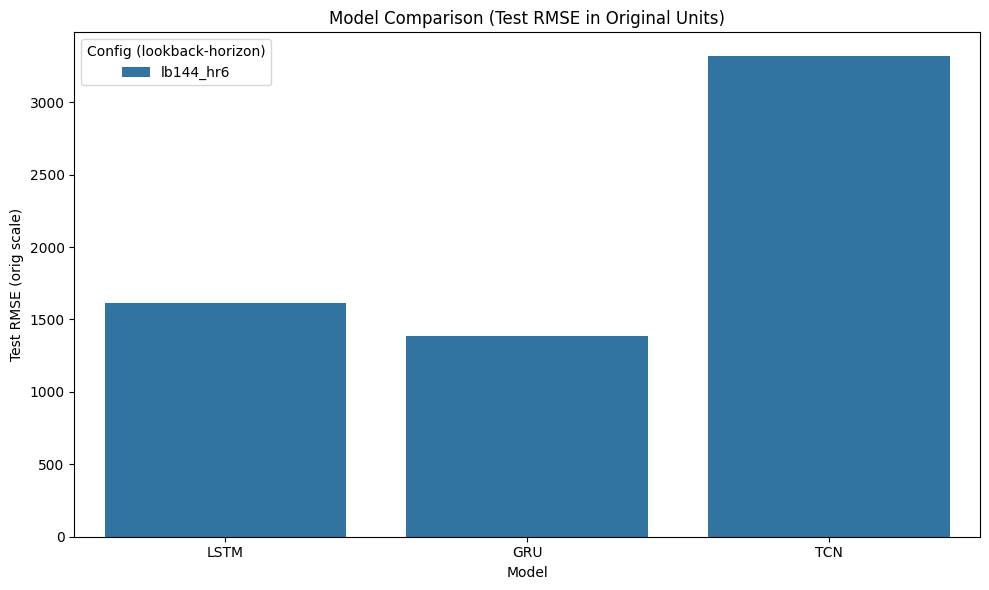

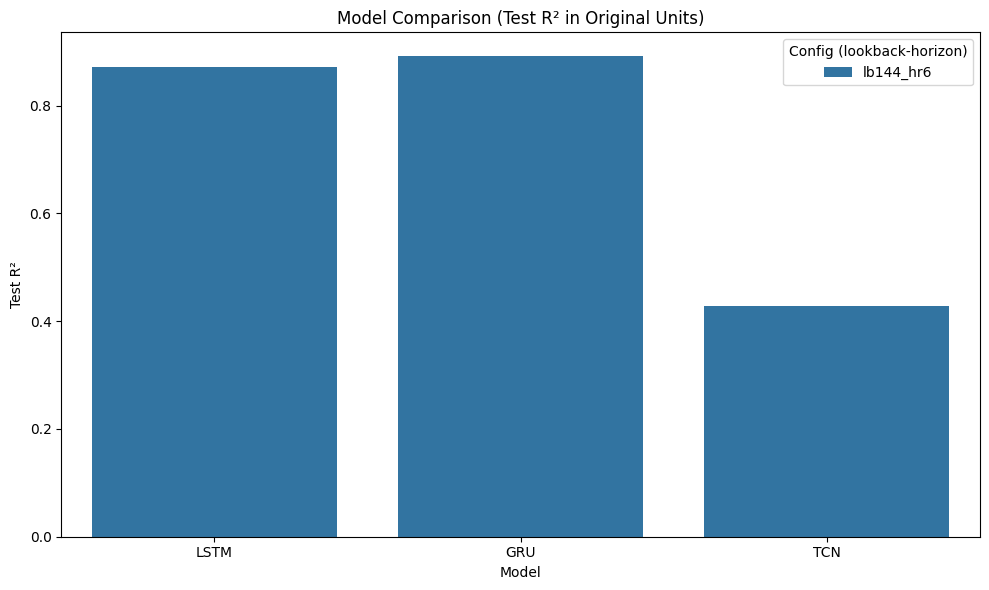

📑 Comparison summary saved to: C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powercast\advanced\submissions\team-members\lakshay-yadav\assets\results\model_comparison_summary.csv


In [44]:
# %% -----------------------------
# 📊 Step 4.6: Compare Models Across Keys (Plots)
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Convert results into a DataFrame
comparison_rows = []
for key, model_dict in results.items():
    for model_name, metrics in model_dict.items():
        comparison_rows.append({
            "key": key,
            "model": model_name.upper(),
            "val_rmse_scaled":  metrics["val_metrics_scaled"]["rmse"],
            "test_rmse_scaled": metrics["test_metrics_scaled"]["rmse"],
            "val_rmse_orig":    metrics["val_metrics_orig"]["rmse"],
            "test_rmse_orig":   metrics["test_metrics_orig"]["rmse"],
            "val_mae_orig":     metrics["val_metrics_orig"]["mae"],
            "test_mae_orig":    metrics["test_metrics_orig"]["mae"],
            "val_r2_orig":      metrics["val_metrics_orig"]["r2"],
            "test_r2_orig":     metrics["test_metrics_orig"]["r2"]
        })

comparison_df = pd.DataFrame(comparison_rows)

# ✅ Plot RMSE (Original units) per model
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x="model", y="test_rmse_orig", hue="key")
plt.title("Model Comparison (Test RMSE in Original Units)")
plt.ylabel("Test RMSE (orig scale)")
plt.xlabel("Model")
plt.legend(title="Config (lookback-horizon)")
plt.tight_layout()
plt.show()

# ✅ Plot R² (Original units) per model
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x="model", y="test_r2_orig", hue="key")
plt.title("Model Comparison (Test R² in Original Units)")
plt.ylabel("Test R²")
plt.xlabel("Model")
plt.legend(title="Config (lookback-horizon)")
plt.tight_layout()
plt.show()

# ✅ Save CSV summary for easy reference
comp_csv = assets_dir / "results" / "model_comparison_summary.csv"
comparison_df.to_csv(comp_csv, index=False)
print(f"📑 Comparison summary saved to: {comp_csv}")

### 🧪 Step 4 – Evaluation & Forecasts
- Computes `MSE`, `RMSE`, `MAE`, `R²` on val/test sets.  
- Rebuilds models from checkpoints, evaluates, and logs metrics in `results`.  
- Plots actual vs predicted sequences for a few batches, saved in `assets_dir`.  
- Prints sample predictions for quick inspection.

In [66]:
# -----------------------------
# ✅ Step 5: MLflow Experiment Logging (Using existing MLflow instance)
# -----------------------------

def run_experiment(key, loader_dict, ModelClass, model_name,
                   hidden_dim=64, num_layers=2, kernel_size=3,
                   dropout=0.2, lr=1e-3, epochs=10, patience=3,
                   TRAIN_LOSS="mse", assets_dir="assets", device="cpu",
                   mlflow_experiment_name="baseline_experiments"):

    # Set MLflow experiment (existing instance)
    mlflow.set_experiment(mlflow_experiment_name)

    # Infer input_dim, horizon, target_dim
    X_sample, y_sample = loader_dict["train"].dataset.tensors
    input_dim = X_sample.shape[-1]
    horizon = y_sample.shape[1] if y_sample.ndim > 1 else 1
    target_dim = y_sample.shape[2] if y_sample.ndim > 2 else 1

    criterion, loss_name = make_criterion(TRAIN_LOSS)

    # Build model
    if model_name in ["lstm", "gru"]:
        model = ModelClass(input_dim=input_dim, hidden_dim=hidden_dim,
                           horizon=horizon, target_dim=target_dim,
                           num_layers=num_layers).to(device)
    else:  # tcn
        try:
            model = ModelClass(input_dim=input_dim, hidden_dim=hidden_dim,
                               horizon=horizon, target_dim=target_dim,
                               kernel_size=kernel_size, dropout=dropout).to(device)
        except TypeError:
            model = ModelClass(input_dim=input_dim, horizon=horizon, target_dim=target_dim).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    checkpoint_file = os.path.join(assets_dir, f"{key}_{model_name}_best.pt")
    final_model_file = os.path.join(assets_dir, f"{key}_{model_name}_final.pt")

    # --- MLflow run ---
    with mlflow.start_run(run_name=f"{key}_{model_name}"):

        # Log hyperparams
        mlflow.log_params({
            "model_name": model_name,
            "input_dim": input_dim,
            "horizon": horizon,
            "target_dim": target_dim,
            "hidden_dim": hidden_dim,
            "num_layers": num_layers if model_name in ["lstm", "gru"] else None,
            "kernel_size": kernel_size if model_name == "tcn" else None,
            "dropout": dropout if model_name == "tcn" else None,
            "lr": lr,
            "epochs": epochs,
            "patience": patience,
            "loss_fn": loss_name
        })

        # Train model
        model, best_val_loss, best_epoch, epochs_ran, wall_time = train_model(
            model, loader_dict["train"], loader_dict["val"],
            criterion, optimizer,
            epochs=epochs, patience=patience,
            checkpoint_path=checkpoint_file,
            device=device
        )

        # Save final model
        torch.save(model.state_dict(), final_model_file)
        mlflow.pytorch.log_model(model, artifact_path="model")

        # Evaluate (scaled)
        val_metrics = evaluate_model(model, loader_dict["val"], device)
        test_metrics = evaluate_model(model, loader_dict["test"], device)

        # Evaluate (original units)
        lb, hr = key.split("_")
        lb, hr = lb.replace("lb", ""), hr.replace("hr", "")
        scaler_path = os.path.join(assets_dir, "scalers", f"y_scaler_lb{lb}_hr{hr}.pkl")
        y_scaler = joblib.load(scaler_path)

        val_metrics_orig = evaluate_model_orig(model, loader_dict["val"], y_scaler, device)
        test_metrics_orig = evaluate_model_orig(model, loader_dict["test"], y_scaler, device)

        # Log metrics
        mlflow.log_metrics({
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
            "epochs_ran": epochs_ran,
            "train_seconds": wall_time,
            "val_rmse": val_metrics["rmse"],
            "val_mae": val_metrics["mae"],
            "val_r2": val_metrics["r2"],
            "test_rmse": test_metrics["rmse"],
            "test_mae": test_metrics["mae"],
            "test_r2": test_metrics["r2"],
            "val_rmse_orig": val_metrics_orig["rmse"],
            "test_rmse_orig": test_metrics_orig["rmse"]
        })

        # Plot sample forecasts
        fig, ax = plt.subplots(figsize=(12,5))
        model.eval()
        Xb, yb = next(iter(loader_dict["test"]))
        Xb, yb = Xb.to(device), yb.to(device)
        if yb.ndim == 2:
            yb = yb.unsqueeze(-1)
        with torch.no_grad():
            y_pred = model(Xb)
        ax.plot(yb[0].squeeze().cpu().numpy(), label="Actual", marker="o")
        ax.plot(y_pred[0].squeeze().cpu().numpy(), label="Predicted", marker="x")
        ax.set_title(f"{model_name.upper()} Forecast Sample ({key})")
        ax.legend()
        mlflow.log_figure(fig, "forecast_sample.png")
        plt.close(fig)

    return model, val_metrics, test_metrics, val_metrics_orig, test_metrics_orig

In [67]:
# -----------------------------
# ✅ Step 5.4: MLflow Logging Patch (fix warnings)
# -----------------------------

def safe_log_model(model, loader, run_name="default_model"):
    """
    Wrapper around mlflow.pytorch.log_model to:
      - Convert torch.Tensor to numpy for input_example
      - Use artifact_path properly (avoids deprecation issues)
    """
    # Get example input from test loader
    example_input, _ = next(iter(loader))
    example_input_np = example_input[:1].cpu().numpy()   # ✅ numpy format

    mlflow.pytorch.log_model(
        model,
        name="models",           # keep artifact_path (PyTorch flavor expects this)
        input_example=example_input_np    # fixes the signature warning
    )

In [79]:
# -----------------------------
# ✅ Step 5.5: Evaluate & Log All Baselines (Scaled + Original Metrics)
# -----------------------------
baseline_models = {
    "lstm": LSTMForecast,
    "gru": GRUForecast,
    "tcn": TCNForecast,
}

all_results = {}

for key, loader_dict in dataloaders.items():
    print(f"\n📊 Evaluating baselines for dataset: {key}")
    all_results[key] = {}

    # Infer input/output dims (same logic as Step 3)
    X_sample, y_sample = loader_dict["train"].dataset.tensors
    input_dim = X_sample.shape[-1]
    if y_sample.ndim == 3:
        horizon, target_dim = y_sample.shape[1], y_sample.shape[2]
    elif y_sample.ndim == 2:
        horizon, target_dim = y_sample.shape[1], 1
    else:
        horizon, target_dim = 1, 1

    # -----------------------------
    # ✅ Load scaler and rebuild scaled loaders
    # -----------------------------
    lb, hr = key.split("_")
    lb, hr = lb.replace("lb", ""), hr.replace("hr", "")
    scaler_path = os.path.join(assets_dir, "scalers", f"y_scaler_lb{lb}_hr{hr}.pkl")
    y_scaler = joblib.load(scaler_path)

    # 🔍 Sanity check
    y_batch = y_sample[:5].cpu().numpy().reshape(-1, target_dim)
    y_scaled = y_scaler.transform(y_batch)
    y_inverted = y_scaler.inverse_transform(y_scaled)
    print(f"🔍 Sanity Check [{key}] | "
          f"Orig[0]={y_batch[0,0]:.4f}, "
          f"Scaled[0]={y_scaled[0,0]:.4f}, "
          f"Inverted[0]={y_inverted[0,0]:.4f}")

    # ✅ Build scaled loaders
    val_loader_scaled  = build_scaled_loader(loader_dict["val"],  y_scaler)
    test_loader_scaled = build_scaled_loader(loader_dict["test"], y_scaler)

    for model_name, ModelClass in baseline_models.items():
        print(f"\n⚡ Evaluating {model_name.upper()} for {key}")

        # Rebuild model (same arch as Step 3)
        if model_name in ["lstm", "gru"]:
            model = ModelClass(
                input_dim=input_dim, hidden_dim=64,
                horizon=horizon, target_dim=target_dim,
                num_layers=2
            ).to(device)
        elif model_name == "tcn":
            model = ModelClass(
                input_dim=input_dim, hidden_dim=64,
                horizon=horizon, target_dim=target_dim,
                kernel_size=3, dropout=0.2
            ).to(device)

        # Ensure trained weights exist
        final_model_file = os.path.join(assets_dir, f"{key}_{model_name}_final.pt")
        if not os.path.exists(final_model_file):
            raise FileNotFoundError(
                f"❌ Missing trained weights: {final_model_file}. "
                f"Run Step 3 before Step 5.5."
            )

        # Load trained weights
        model.load_state_dict(torch.load(final_model_file, map_location=device))
        model.eval()

        # -----------------------------
        # ✅ Metrics
        # -----------------------------
        val_metrics_scaled  = evaluate_model(model, val_loader_scaled,  device)
        test_metrics_scaled = evaluate_model(model, test_loader_scaled, device)

        val_metrics_orig  = evaluate_model_orig(model, val_loader_scaled,  y_scaler, device)
        test_metrics_orig = evaluate_model_orig(model, test_loader_scaled, y_scaler, device)

        # -----------------------------
        # ✅ MLflow Logging
        # -----------------------------
        with mlflow.start_run(run_name=f"{model_name}_{key}", nested=True):
            mlflow.log_params({"dataset": key, "model": model_name})

            mlflow.log_metrics({f"val_{m}_scaled": v for m, v in val_metrics_scaled.items()})
            mlflow.log_metrics({f"test_{m}_scaled": v for m, v in test_metrics_scaled.items()})
            mlflow.log_metrics({f"val_{m}_original": v for m, v in val_metrics_orig.items()})
            mlflow.log_metrics({f"test_{m}_original": v for m, v in test_metrics_orig.items()})

            safe_log_model(model, test_loader_scaled, run_name=f"{key}_{model_name}")

            forecast_path = plot_forecasts(
                model, test_loader_scaled, key, model_name, assets_dir,
                num_batches=3, scaler=y_scaler
            )
            mlflow.log_artifact(forecast_path)

        # Save results locally
        all_results[key][model_name] = {
            "val_metrics_scaled": val_metrics_scaled,
            "test_metrics_scaled": test_metrics_scaled,
            "val_metrics_original": val_metrics_orig,
            "test_metrics_original": test_metrics_orig
        }

        print(f"✅ {model_name.upper()} | {key} | "
              f"Val RMSE (orig)={val_metrics_orig['rmse']:.2f}, "
              f"Test RMSE (orig)={test_metrics_orig['rmse']:.2f}")


📊 Evaluating baselines for dataset: lb144_hr6
🔍 Sanity Check [lb144_hr6] | Orig[0]=26703.7969, Scaled[0]=-0.8655, Inverted[0]=26703.7969

⚡ Evaluating LSTM for lb144_hr6
✅ LSTM | lb144_hr6 | Val RMSE (orig)=1010.66, Test RMSE (orig)=1612.24

⚡ Evaluating GRU for lb144_hr6
✅ GRU | lb144_hr6 | Val RMSE (orig)=864.74, Test RMSE (orig)=1387.82

⚡ Evaluating TCN for lb144_hr6
✅ TCN | lb144_hr6 | Val RMSE (orig)=2042.73, Test RMSE (orig)=3316.57


In [80]:
# -----------------------------
# ✅ Step 5.6: Save all_results persistently
# -----------------------------
from pathlib import Path
import json

results_dir = Path(r"C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powercast\advanced\submissions\team-members\lakshay-yadav\assets\results")
results_dir.mkdir(parents=True, exist_ok=True)

results_path = results_dir / "all_results.json"
with open(results_path, "w") as f:
    json.dump(all_results, f, indent=2)

print(f"\n💾 all_results saved to {results_path}")


💾 all_results saved to C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powercast\advanced\submissions\team-members\lakshay-yadav\assets\results\all_results.json


### 🧪 Step 5 – MLflow Logging & Baseline Evaluation
- Runs experiments on LSTM, GRU, TCN using MLflow, logging hyperparameters, metrics, models, and forecast plots.  
- Rebuilds trained models from Step 3, evaluates on val/test sets, and saves metrics in `all_results`.  
- Supports nested MLflow runs for multiple datasets and models.  
- Forecast plots and models are stored in `assets_dir` and logged as artifacts.

In [81]:
# -----------------------------
# ✅ Step 6: Save Trained Models + Metadata
# -----------------------------
from pathlib import Path
plots_dir = Path(r"C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powercast\advanced\submissions\team-members\lakshay-yadav\assets\plots")
assets_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

# Reload all_results from JSON to avoid stale data
results_path = results_dir / "all_results.json"
if results_path.exists():
    with open(results_path, "r") as f:
        all_results = json.load(f)
    print("🔄 Reloaded all_results from JSON")
else:
    all_results = {}
    print("⚠️ No saved results found, run Step 5.5 first.")

def build_metadata_record(key, model_name, input_dim, target_dim, hidden_dim, num_layers,
                          best_val_loss, val_metrics, test_metrics, checkpoint_file, plot_file):
    parts = key.split("_")  # expected: zone_lbXX_hrYY
    lookback = int(parts[2].replace("lb", "")) if len(parts) > 2 else None
    horizon  = int(parts[3].replace("hr", "")) if len(parts) > 3 else None

    return {
        "key": key,
        "model_name": model_name,
        "lookback": lookback,
        "horizon": horizon,
        "input_dim": int(input_dim),
        "target_dim": int(target_dim),
        "model": model_name.upper(),
        "hidden_dim": int(hidden_dim),
        "num_layers": int(num_layers),
        "optimizer": "Adam",
        "loss_fn": "MSELoss",
        "best_val_loss": float(best_val_loss),
        "val": val_metrics,
        "test": test_metrics,
        "artifacts": {
            "checkpoint_path": str(checkpoint_file),
            "forecast_plot": str(plot_file) if plot_file is not None else None
        },
        "timestamp": str(pd.Timestamp.now())
    }

# Collect rows for CSV
summary_rows = []

for key, loader_dict in dataloaders.items():
    if key not in all_results or not all_results[key]:
        continue

    X_sample, y_sample = loader_dict["train"].dataset.tensors
    input_dim = X_sample.shape[-1]
    target_dim = y_sample.shape[2] if y_sample.ndim == 3 else 1

    for model_name in all_results[key]:
        checkpoint_file = str((assets_dir / f"best_model_{key}_{model_name}.pt").resolve())
        plot_file = str((plots_dir / f"forecast_{key}_{model_name}.png").resolve())
        plot_file = plot_file if os.path.exists(plot_file) else None

        val_metrics  = all_results[key][model_name]["val_metrics_original"]
        test_metrics = all_results[key][model_name]["test_metrics_original"]
        best_val_loss = val_metrics["rmse"]

        meta = build_metadata_record(
            key, model_name, input_dim, target_dim,
            hidden_dim=64, num_layers=2,
            best_val_loss=best_val_loss,
            val_metrics=val_metrics, test_metrics=test_metrics,
            checkpoint_file=checkpoint_file, plot_file=plot_file
        )
        meta_path = assets_dir / f"best_model_{key}_{model_name}.json"
        with open(meta_path, "w") as f:
            json.dump(meta, f, indent=2)

        # Compute accuracy% = 100 * (1 - RMSE / mean_target)
        test_loader = loader_dict["test"]
        _, y_test = test_loader.dataset.tensors
        mean_target = float(y_test.mean().item())
        accuracy_pct = max(0, 100 * (1 - test_metrics["rmse"] / mean_target))

        summary_rows.append({
            "key": key,
            "model_name": model_name,
            "lookback": meta["lookback"],
            "horizon": meta["horizon"],
            "input_dim": input_dim,
            "target_dim": target_dim,
            "val_rmse": val_metrics["rmse"],
            "val_mae":  val_metrics["mae"],
            "val_r2":   val_metrics["r2"],
            "test_rmse": test_metrics["rmse"],
            "test_mae":  test_metrics["mae"],
            "test_r2":   test_metrics["r2"],
            "accuracy_pct": accuracy_pct,
            "checkpoint_path": checkpoint_file,
            "forecast_plot": plot_file
        })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    summary_csv = results_dir / "week3_results_summary.csv"
    summary_df.to_csv(summary_csv, index=False)
    print(f"\n🗂️ Results summary saved: {summary_csv}")
else:
    print("⚠️ No results were collected — summary CSV not created.")

🔄 Reloaded all_results from JSON

🗂️ Results summary saved: C:\Users\ABCD\_ML projects(SDS)\SDS-CP036-powercast\advanced\submissions\team-members\lakshay-yadav\assets\results\week3_results_summary.csv


In [82]:
# -----------------------------
# ✅ Step 6.5: Notebook Summary Table
# -----------------------------
summary_csv = results_dir / "week3_results_summary.csv"

if summary_csv.exists() and summary_csv.stat().st_size > 0:
    df_sum = pd.read_csv(summary_csv)
    if not df_sum.empty:
        display_cols = ["key", "model_name", "lookback", "horizon", 
                        "val_rmse", "val_mae", "val_r2", 
                        "test_rmse", "test_mae", "test_r2", "accuracy_pct"]
        df_view = df_sum[display_cols].sort_values(by="test_rmse", ascending=True)
        print("🏁 Week 3 — per-config metrics (sorted by Test RMSE):")
        display(df_view.head(10))
    else:
        print("⚠️ Results summary CSV is empty — no rows to show.")
else:
    print(f"⚠️ Summary CSV not found or is empty at {summary_csv}")

🏁 Week 3 — per-config metrics (sorted by Test RMSE):


,key,model_name,lookback,horizon,val_rmse,val_mae,val_r2,test_rmse,test_mae,test_r2,accuracy_pct
1,lb144_hr6,gru,NaN,NaN,864.742411,617.037964,0.960269,1387.822980,1052.590942,0.891343,93.546667
0,lb144_hr6,lstm,NaN,NaN,1010.662530,749.929016,0.948030,1612.238118,1250.540527,0.871325,92.503144
2,lb144_hr6,tcn,NaN,NaN,2042.726120,1618.836060,0.763791,3316.569161,2874.057861,0.427345,84.578059


### 💾 Step 6 – Save Models, Metadata & Summary
- Saves all trained models, metadata JSON, and forecast plots under `assets` (no extra folders).  
- Builds per-model metadata including architecture, hyperparameters, val/test metrics, and artifact paths.  
- Aggregates results into a single CSV: `assets/results/week3_results_summary.csv`.  
- Optional Step 6.5: Displays top configurations sorted by Test RMSE for quick inspection.